# Trabajo 4 — Visualización de datos con Matplotlib y Seaborn

**Dataset:** `superstore_dataset2012.csv` — pedidos de una cadena minorista global durante 2012.

**Objetivo:** analizar las ventas y los beneficios de la tienda mediante visualizaciones univariantes, bivariantes y multivariantes con Matplotlib y Seaborn, y extraer conclusiones útiles para el negocio.

**Contenido**

1. Configuración del entorno
2. Exploración inicial de los datos
3. Preparación y transformación de los datos
4. Visualizaciones univariantes con Matplotlib
5. Visualizaciones univariantes con Seaborn
6. Visualizaciones bivariantes y multivariantes con Matplotlib
7. Visualizaciones bivariantes con Seaborn
8. Visualizaciones multivariantes con Seaborn
9. Panel de visualizaciones con subplots
10. Conclusiones generales

## 1. Configuración del entorno

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Estilo general de todos los gráficos
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titleweight'] = 'bold'

# Colores fijos por categoría para que se reconozcan igual en todos los gráficos
PALETA_CATEGORIAS = {
    'Furniture': '#4C72B0',
    'Office Supplies': '#DD8452',
    'Technology': '#55A868',
}

# Carpeta donde se guardan las figuras
CARPETA_IMAGENES = 'imagenes'
os.makedirs(CARPETA_IMAGENES, exist_ok=True)


def guardar(fig, nombre):
    """Guarda una figura en la carpeta de imágenes con buena resolución."""
    fig.savefig(os.path.join(CARPETA_IMAGENES, nombre), dpi=150, bbox_inches='tight')

## 2. Exploración inicial de los datos

Se carga el CSV y se revisa su estructura: tamaño, tipos de datos, valores nulos, duplicados y estadísticas básicas.

In [2]:
df = pd.read_csv('superstore_dataset2012.csv')

print(f'Filas: {df.shape[0]:,}  |  Columnas: {df.shape[1]}')
df.head()

Filas: 4,246  |  Columnas: 24


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,21896,ID-2012-71858,1/2/2012,7/2/2012,Standard Class,CP-12085,Cathy Prescott,Corporate,Jakarta,Jakarta,...,TEC-PH-10003784,Technology,Phones,"Motorola Signal Booster, with Caller ID",593.9895,5,0.17,-71.7105,52.22,Medium
1,4323,MX-2012-154459,1/2/2012,6/2/2012,Standard Class,JF-15190,Jamie Frazer,Consumer,Santiago,Santiago,...,TEC-PH-10002102,Technology,Phones,"Nokia Headset, Cordless",151.9200,3,0.00,71.4000,32.94,High
2,2829,MX-2012-114461,1/2/2012,5/2/2012,Standard Class,RM-19375,Raymond Messe,Consumer,Escuintla,Escuintla,...,TEC-AC-10002760,Technology,Accessories,"Memorex Memory Card, Erganomic",200.1600,3,0.00,0.0000,28.95,High
3,2828,MX-2012-114461,1/2/2012,5/2/2012,Standard Class,RM-19375,Raymond Messe,Consumer,Escuintla,Escuintla,...,FUR-CH-10001423,Furniture,Chairs,"Harbour Creations Rocking Chair, Black",192.8800,2,0.00,54.0000,19.27,High
4,6762,MX-2012-151904,1/2/2012,3/2/2012,First Class,DJ-13420,Denny Joy,Corporate,Villa Canales,Guatemala,...,OFF-PA-10003571,Office Supplies,Paper,"Enermax Cards & Envelopes, Recycled",94.0200,3,0.00,1.8600,10.73,Medium


In [3]:
# Tipos de datos: las fechas se leen como texto y deben convertirse
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4246 entries, 0 to 4245
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          4246 non-null   int64  
 1   Order ID        4246 non-null   str    
 2   Order Date      4246 non-null   str    
 3   Ship Date       4246 non-null   str    
 4   Ship Mode       4246 non-null   str    
 5   Customer ID     4246 non-null   str    
 6   Customer Name   4246 non-null   str    
 7   Segment         4246 non-null   str    
 8   City            4246 non-null   str    
 9   State           4246 non-null   str    
 10  Country         4246 non-null   str    
 11  Postal Code     823 non-null    float64
 12  Market          4246 non-null   str    
 13  Region          4246 non-null   str    
 14  Product ID      4246 non-null   str    
 15  Category        4246 non-null   str    
 16  Sub-Category    4246 non-null   str    
 17  Product Name    4246 non-null   str    
 18 

In [4]:
# Valores nulos por columna (solo las que tienen alguno)
nulos = df.isna().sum()
nulos[nulos > 0].to_frame('nulos').assign(porcentaje=lambda t: (t['nulos'] / len(df) * 100).round(1))

,nulos,porcentaje
Postal Code,3423,80.6


In [5]:
# Duplicados y número de valores distintos en las columnas categóricas principales
print('Filas duplicadas:', df.duplicated().sum())
print('Row ID repetidos:', df['Row ID'].duplicated().sum())
print('Pedidos distintos:', df['Order ID'].nunique())
print()
df[['Segment', 'Market', 'Category', 'Sub-Category', 'Ship Mode', 'Order Priority', 'Country']].nunique()

Filas duplicadas: 0
Row ID repetidos: 0
Pedidos distintos: 2127



Segment             3
Market              7
Category            3
Sub-Category       17
Ship Mode           4
Order Priority      4
Country           112
dtype: int64

In [6]:
# Estadísticas de las variables numéricas
df[['Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost']].describe().round(2)

,Sales,Quantity,Discount,Profit,Shipping Cost
count,4246.00,4246.00,4246.00,4246.00,4246.00
mean,237.03,3.44,0.15,27.70,24.54
std,426.97,2.23,0.22,147.46,50.42
min,1.11,1.00,0.00,-1806.24,0.03
25%,30.56,2.00,0.00,-0.06,2.61
50%,82.53,3.00,0.00,9.03,7.60
75%,245.81,5.00,0.20,35.90,23.53
max,5759.96,14.00,0.80,2229.02,759.47


**Observaciones de la exploración**

- 4.246 líneas de pedido (2.127 pedidos distintos) y 24 columnas, sin filas duplicadas.
- `Order Date` y `Ship Date` están guardadas como **texto**, y además en **dos formatos distintos**: `1/2/2012` (con `/`) y `13-01-2012` (con `-`).
- `Postal Code` está vacía en el 80,6 % de las filas (solo existe para pedidos de EE. UU.), así que no aporta al análisis.
- `Sales` y `Profit` tienen medias mucho mayores que sus medianas (237 frente a 83 en ventas): hay pocos pedidos muy grandes que sesgan la distribución. `Profit` tiene valores negativos (pérdidas).

## 3. Preparación y transformación de los datos

### 3.1 Conversión de fechas

Antes de convertir hay que saber si el formato es día/mes o mes/día. Se comprueba con los datos:

- En las fechas con `-` la primera parte llega hasta 19, así que **es el día** (`dd-mm-aaaa`).
- Si las fechas con `/` se leen como día/mes, el tiempo de envío queda siempre entre 0 y 7 días; leídas como mes/día saldrían envíos negativos o de más de 200 días. Por tanto también son **día/mes**.

Se unifica el separador y se convierte con un formato explícito.

In [7]:
# Comprobación: primera parte de las fechas según el separador
for columna in ['Order Date', 'Ship Date']:
    for sep in ['/', '-']:
        partes = df.loc[df[columna].str.contains(sep, regex=False), columna].str.split(sep, expand=True)
        if len(partes):
            print(f'{columna:10} sep {sep!r}: {len(partes):>4} filas, primera parte entre '
                  f'{partes[0].astype(int).min()} y {partes[0].astype(int).max()}')

Order Date sep '/': 4246 filas, primera parte entre 1 y 12
Ship Date  sep '/': 2835 filas, primera parte entre 1 y 12
Ship Date  sep '-': 1411 filas, primera parte entre 13 y 19


In [8]:
# Conversión: se reemplaza '-' por '/' y se interpreta como día/mes/año
for columna in ['Order Date', 'Ship Date']:
    df[columna] = pd.to_datetime(df[columna].str.replace('-', '/', regex=False), format='%d/%m/%Y')

# Validación: ningún envío puede ser anterior al pedido
df['Dias Envio'] = (df['Ship Date'] - df['Order Date']).dt.days
print('Días de envío: mínimo', df['Dias Envio'].min(), '| máximo', df['Dias Envio'].max())
print('Rango de pedidos:', df['Order Date'].min().date(), 'a', df['Order Date'].max().date())
df[['Order Date', 'Ship Date']].dtypes

Días de envío: mínimo 0 | máximo 7
Rango de pedidos: 2012-01-02 a 2012-12-12


Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object

> **Nota:** todas las fechas de pedido caen entre los días 1 y 12 de cada mes. Es una característica de esta muestra del dataset, así que los totales mensuales sirven para comparar meses entre sí, pero no representan el mes completo.

### 3.2 Limpieza y nuevas columnas

In [9]:
# Postal Code: 80 % nulos y no se usa en el análisis -> se elimina
df = df.drop(columns=['Postal Code'])

# Columnas derivadas para el análisis
df['Mes'] = df['Order Date'].dt.to_period('M').dt.to_timestamp()   # primer día del mes del pedido
df['Margen %'] = (df['Profit'] / df['Sales'] * 100).round(2)        # beneficio sobre ventas
df['Rango Descuento'] = pd.cut(df['Discount'], bins=[-0.01, 0, 0.2, 0.4, 1],
                               labels=['Sin descuento', '1-20 %', '21-40 %', 'Más de 40 %'])

# Variables categóricas como 'category' (menos memoria y orden controlado)
for columna in ['Segment', 'Market', 'Category', 'Ship Mode']:
    df[columna] = df[columna].astype('category')
df['Ship Mode'] = df['Ship Mode'].cat.reorder_categories(
    ['Same Day', 'First Class', 'Second Class', 'Standard Class'], ordered=True)

print('Nulos restantes:', df.isna().sum().sum())
df[['Order Date', 'Ship Date', 'Dias Envio', 'Mes', 'Sales', 'Profit', 'Margen %', 'Rango Descuento']].head()

Nulos restantes: 0


,Order Date,Ship Date,Dias Envio,Mes,Sales,Profit,Margen %,Rango Descuento
0,2012-02-01,2012-02-07,6,2012-02-01,593.9895,-71.7105,-12.07,1-20 %
1,2012-02-01,2012-02-06,5,2012-02-01,151.9200,71.4000,47.00,Sin descuento
2,2012-02-01,2012-02-05,4,2012-02-01,200.1600,0.0000,0.00,Sin descuento
3,2012-02-01,2012-02-05,4,2012-02-01,192.8800,54.0000,28.00,Sin descuento
4,2012-02-01,2012-02-03,2,2012-02-01,94.0200,1.8600,1.98,Sin descuento


## 4. Visualizaciones univariantes con Matplotlib

### 4.1 Histograma de ventas por línea de pedido

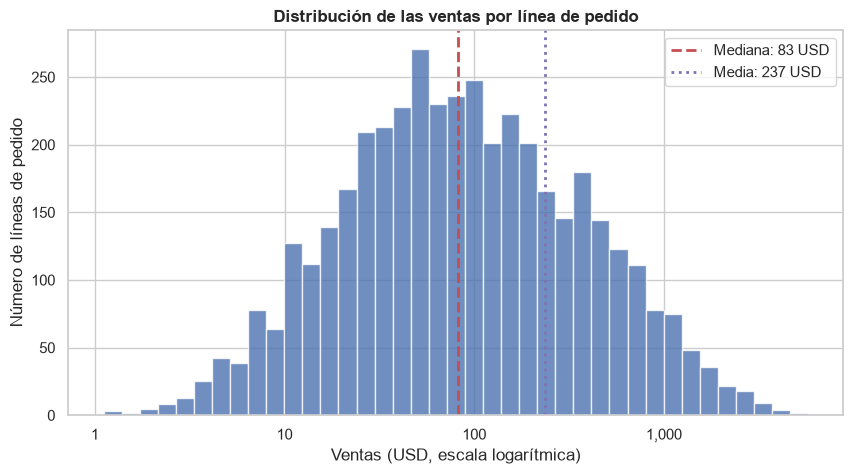

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

# Las ventas van de 1 a más de 5.000: con bins logarítmicos se ve toda la distribución
bins = np.logspace(np.log10(df['Sales'].min()), np.log10(df['Sales'].max()), 40)
ax.hist(df['Sales'], bins=bins, color='#4C72B0', alpha=0.8, edgecolor='white')
ax.set_xscale('log')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

media, mediana = df['Sales'].mean(), df['Sales'].median()
ax.axvline(mediana, color='#C44E52', linestyle='--', linewidth=2, label=f'Mediana: {mediana:,.0f} USD')
ax.axvline(media, color='#8172B3', linestyle=':', linewidth=2, label=f'Media: {media:,.0f} USD')

ax.set_title('Distribución de las ventas por línea de pedido')
ax.set_xlabel('Ventas (USD, escala logarítmica)')
ax.set_ylabel('Número de líneas de pedido')
ax.legend()
guardar(fig, '01_histograma_ventas.png')
plt.show()

# Conclusión: la distribución está muy sesgada a la derecha. La mitad de las líneas vende
# menos de 83 USD y el 90 % menos de 621 USD, pero unas pocas ventas grandes (hasta 5.760 USD)
# elevan la media a 237 USD. Para describir una venta "típica" es mejor la mediana que la media.

**Conclusión:** las ventas están muy sesgadas a la derecha. La mitad de las líneas de pedido vende menos de 83 USD y el 90 % menos de 621 USD, pero unos pocos pedidos grandes elevan la media a 237 USD. La mediana describe mejor una venta típica.

### 4.2 Diagrama de barras: pedidos por segmento de cliente

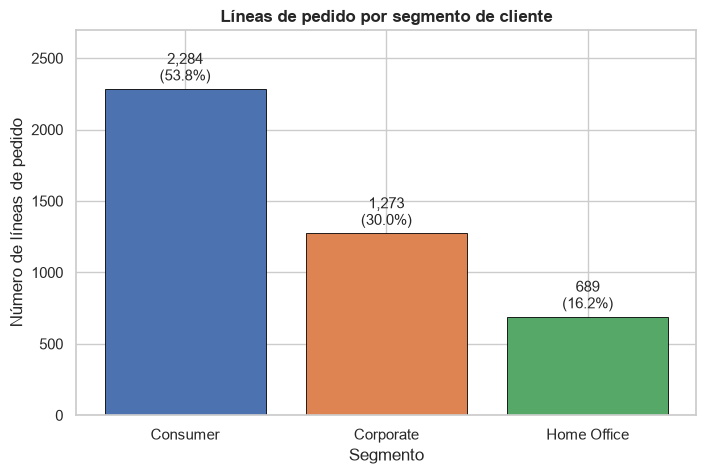

In [11]:
conteo_segmento = df['Segment'].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
barras = ax.bar(conteo_segmento.index, conteo_segmento.values,
                color=['#4C72B0', '#DD8452', '#55A868'], edgecolor='black', linewidth=0.6)

# Etiqueta con el número y el porcentaje encima de cada barra
for barra, valor in zip(barras, conteo_segmento.values):
    ax.annotate(f'{valor:,}\n({valor / len(df):.1%})',
                (barra.get_x() + barra.get_width() / 2, valor),
                ha='center', va='bottom', fontsize=11, xytext=(0, 3), textcoords='offset points')

ax.set_title('Líneas de pedido por segmento de cliente')
ax.set_xlabel('Segmento')
ax.set_ylabel('Número de líneas de pedido')
ax.set_ylim(0, conteo_segmento.max() * 1.18)
guardar(fig, '02_barras_segmento.png')
plt.show()

# Conclusión: el segmento Consumer (clientes particulares) genera más de la mitad de la
# actividad (53,8 %), seguido de Corporate (30 %) y Home Office (16,2 %). Cualquier acción
# comercial dirigida a Consumer tiene el mayor alcance.

**Conclusión:** el segmento **Consumer** concentra más de la mitad de las líneas de pedido (53,8 %), seguido de Corporate (30 %) y Home Office (16,2 %).

## 5. Visualizaciones univariantes con Seaborn

### 5.1 Diagrama de caja: beneficio por categoría

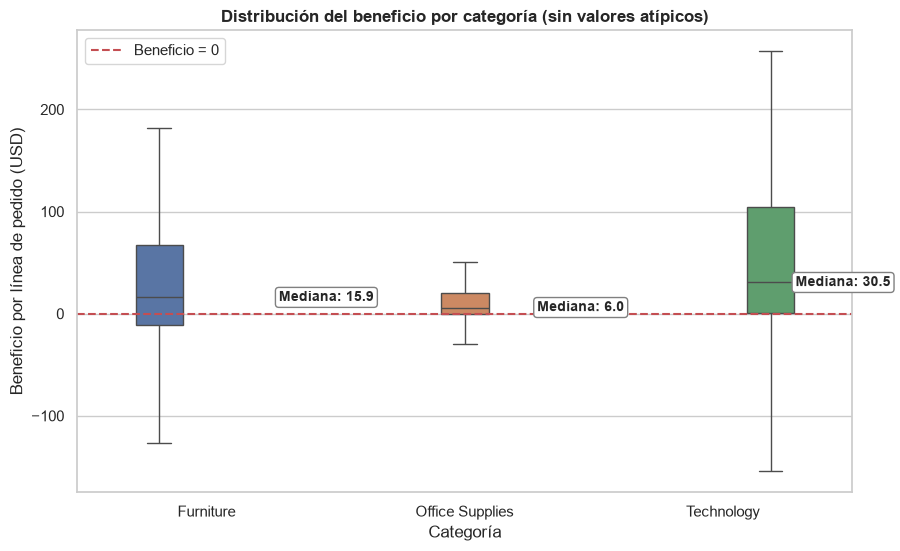

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(data=df, x='Category', y='Profit', hue='Category', palette=PALETA_CATEGORIAS,
            legend=False, showfliers=False, width=0.55, ax=ax)
ax.axhline(0, color='#C44E52', linestyle='--', linewidth=1.5, label='Beneficio = 0')

# Mediana escrita a la derecha de cada caja
medianas = df.groupby('Category', observed=True)['Profit'].median()
for i, categoria in enumerate(medianas.index):
    ax.annotate(f'Mediana: {medianas[categoria]:.1f}', xy=(i + 0.28, medianas[categoria]),
                ha='left', va='center', fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='grey'))

ax.set_title('Distribución del beneficio por categoría (sin valores atípicos)')
ax.set_xlabel('Categoría')
ax.set_ylabel('Beneficio por línea de pedido (USD)')
ax.legend(loc='upper left')
guardar(fig, '03_boxplot_beneficio_categoria.png')
plt.show()

# Conclusión: Technology tiene el beneficio típico más alto (mediana 30,5 USD) y también la mayor
# variabilidad. Office Supplies deja poco beneficio por línea (mediana 6 USD) pero muy estable.
# En Furniture, el primer cuartil ya es negativo (-10,7 USD): más de un 25 % de sus líneas pierden dinero.

**Conclusión:** **Technology** tiene el beneficio típico más alto (mediana 30,5 USD) y la mayor dispersión. **Office Supplies** deja poco beneficio por línea (mediana 6 USD), pero es muy estable. En **Furniture**, el primer cuartil ya es negativo: más de un 25 % de sus líneas generan pérdidas.

### 5.2 Gráfico de violín: días de envío según el modo de envío

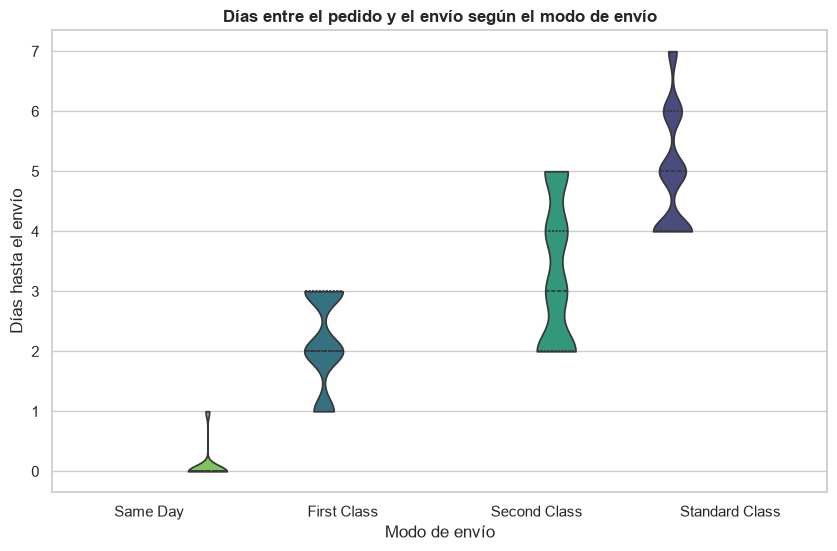

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.violinplot(data=df, x='Ship Mode', y='Dias Envio', hue='Ship Mode', palette='viridis',
               legend=False, inner='quartile', cut=0, density_norm='width', ax=ax)

ax.set_title('Días entre el pedido y el envío según el modo de envío')
ax.set_xlabel('Modo de envío')
ax.set_ylabel('Días hasta el envío')
ax.set_yticks(range(0, 8))
guardar(fig, '04_violin_dias_envio.png')
plt.show()

# Conclusión: cada modo de envío tiene un rango de días bien definido y sin solapes grandes:
# Same Day sale el mismo día (0-1), First Class en 1-3 días, Second Class en 2-5 y Standard Class
# en 4-7. La empresa cumple la promesa de cada modo; Standard Class, el más usado, es el más lento.

**Conclusión:** cada modo de envío tiene un rango de días bien definido: **Same Day** sale en 0-1 días, **First Class** en 1-3, **Second Class** en 2-5 y **Standard Class** en 4-7. La empresa cumple lo que promete cada modo.

## 6. Visualizaciones bivariantes y multivariantes con Matplotlib

### 6.1 Gráfico de líneas: evolución mensual de ventas y beneficio (bivariante temporal)

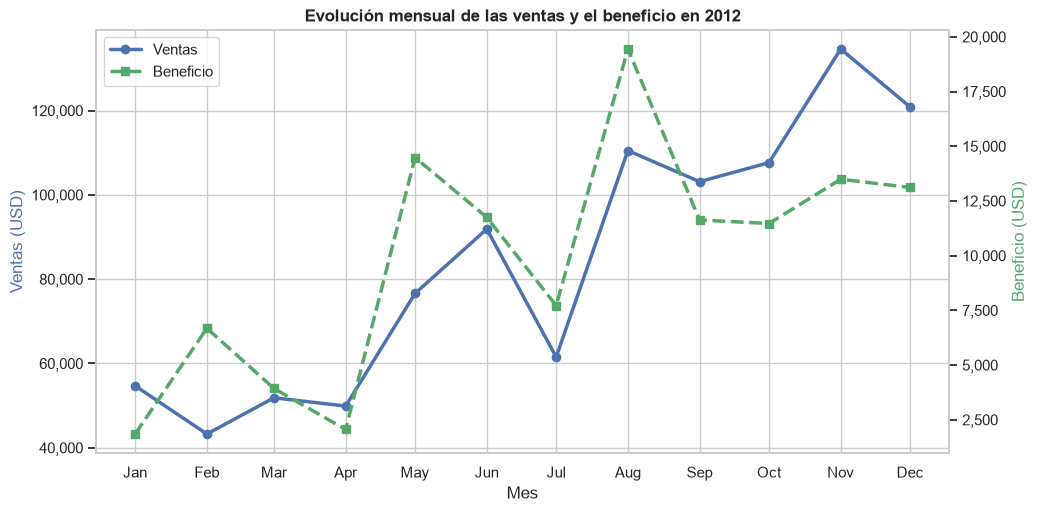

In [14]:
mensual = df.groupby('Mes')[['Sales', 'Profit']].sum()

fig, ax_ventas = plt.subplots(figsize=(11, 5.5))
ax_beneficio = ax_ventas.twinx()   # segundo eje Y: el beneficio es unas 10 veces menor que las ventas

linea_v, = ax_ventas.plot(mensual.index, mensual['Sales'], marker='o', linewidth=2.5,
                          color='#4C72B0', label='Ventas')
linea_b, = ax_beneficio.plot(mensual.index, mensual['Profit'], marker='s', linewidth=2.5,
                             linestyle='--', color='#55A868', label='Beneficio')

ax_ventas.set_title('Evolución mensual de las ventas y el beneficio en 2012')
ax_ventas.set_xlabel('Mes')
ax_ventas.set_ylabel('Ventas (USD)', color='#4C72B0')
ax_beneficio.set_ylabel('Beneficio (USD)', color='#55A868')
ax_ventas.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
ax_beneficio.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
ax_beneficio.grid(False)
ax_ventas.set_xticks(mensual.index)
ax_ventas.set_xticklabels(mensual.index.strftime('%b'))
ax_ventas.legend(handles=[linea_v, linea_b], loc='upper left')
guardar(fig, '05_lineas_evolucion_mensual.png')
plt.show()

# Conclusión: las ventas crecen a lo largo del año: pasan de unos 43.000-55.000 USD en el primer
# trimestre a más de 120.000 USD en noviembre y diciembre (máximo en noviembre, 134.600 USD).
# El beneficio no sigue exactamente a las ventas: su mejor mes es agosto (19.400 USD) y enero y
# abril apenas superan los 2.000 USD, lo que indica meses con más descuentos o pedidos poco rentables.

**Conclusión:** las ventas crecen durante el año, desde unos 43.000-55.000 USD al mes en el primer trimestre hasta más de 120.000 USD en noviembre y diciembre. El beneficio no sigue exactamente a las ventas: su máximo es en **agosto** (19.400 USD), mientras que enero y abril apenas superan los 2.000 USD.

### 6.2 Gráfico de dispersión multivariante: ventas, beneficio, descuento y cantidad

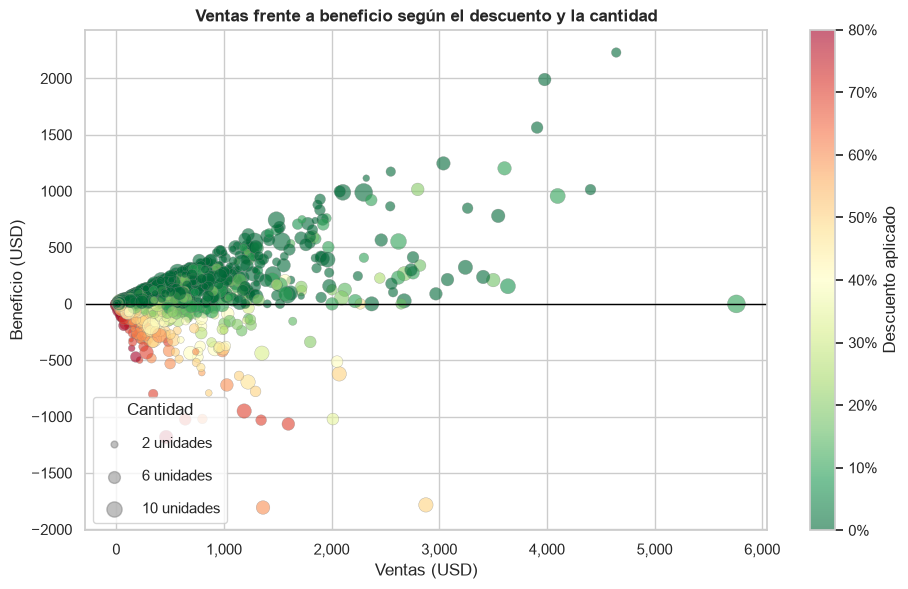

In [15]:
fig, ax = plt.subplots(figsize=(11, 6.5))

# 4 variables en un gráfico: posición (ventas, beneficio), color (descuento) y tamaño (cantidad)
puntos = ax.scatter(df['Sales'], df['Profit'], c=df['Discount'], s=df['Quantity'] * 12,
                    cmap='RdYlGn_r', alpha=0.6, edgecolor='grey', linewidth=0.3)
ax.axhline(0, color='black', linewidth=1)

barra = fig.colorbar(puntos, ax=ax)
barra.set_label('Descuento aplicado')
barra.ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

# Leyenda de tamaños
for cantidad in [2, 6, 10]:
    ax.scatter([], [], s=cantidad * 12, color='grey', alpha=0.5, label=f'{cantidad} unidades')
ax.legend(title='Cantidad', loc='lower left', labelspacing=1.2)

ax.set_title('Ventas frente a beneficio según el descuento y la cantidad')
ax.set_xlabel('Ventas (USD)')
ax.set_ylabel('Beneficio (USD)')
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
guardar(fig, '06_dispersion_multivariante.png')
plt.show()

# Conclusión: en general, a más ventas más beneficio (correlación 0,48), pero la nube se abre en
# dos: los puntos verdes (sin descuento) quedan por encima de 0, mientras que casi todas las
# pérdidas grandes (puntos rojos por debajo de 0) tienen descuentos altos. Una venta grande con
# mucho descuento puede generar pérdidas de más de 1.000 USD.

**Conclusión:** en general, a más ventas más beneficio, pero la nube se separa en dos: los puntos **verdes** (sin descuento) quedan por encima de 0, mientras que casi todas las pérdidas grandes (puntos **rojos**) tienen descuentos altos. Una venta grande con mucho descuento puede perder más de 1.000 USD.

## 7. Visualizaciones bivariantes con Seaborn

### 7.1 Gráfico de barras agrupadas: ventas por mercado y categoría

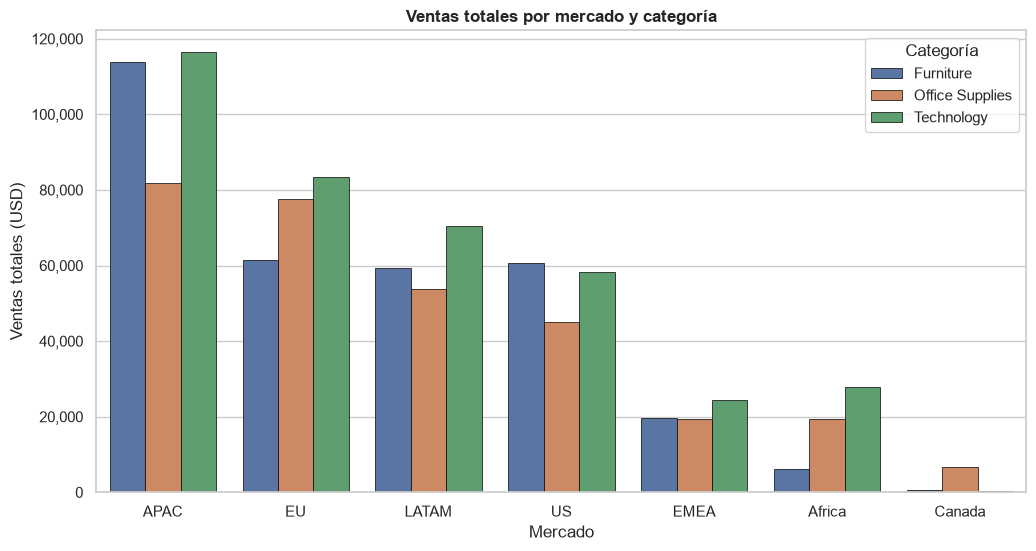

In [16]:
orden_mercados = df.groupby('Market', observed=True)['Sales'].sum().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=df, x='Market', y='Sales', hue='Category', estimator='sum', errorbar=None,
            order=orden_mercados, palette=PALETA_CATEGORIAS, edgecolor='black', linewidth=0.5, ax=ax)

ax.set_title('Ventas totales por mercado y categoría')
ax.set_xlabel('Mercado')
ax.set_ylabel('Ventas totales (USD)')
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
ax.legend(title='Categoría')
guardar(fig, '07_barras_agrupadas_mercado_categoria.png')
plt.show()

# Conclusión: APAC es el mayor mercado (312.000 USD), seguido de EU y LATAM. Technology es la
# categoría que más vende en 5 de los 7 mercados; en US gana Furniture por poco y en Canada, que
# apenas tiene ventas, casi todo es Office Supplies. En APAC, Furniture casi iguala a Technology.

**Conclusión:** **APAC** es el mayor mercado (312.000 USD), seguido de **EU** y **LATAM**. **Technology** es la categoría que más vende en 5 de los 7 mercados; en **US** gana Furniture por poco y en **Canada**, que apenas tiene ventas, casi todo es Office Supplies. En APAC, Furniture casi iguala a Technology.

### 7.2 Gráfico de regresión: descuento frente a beneficio

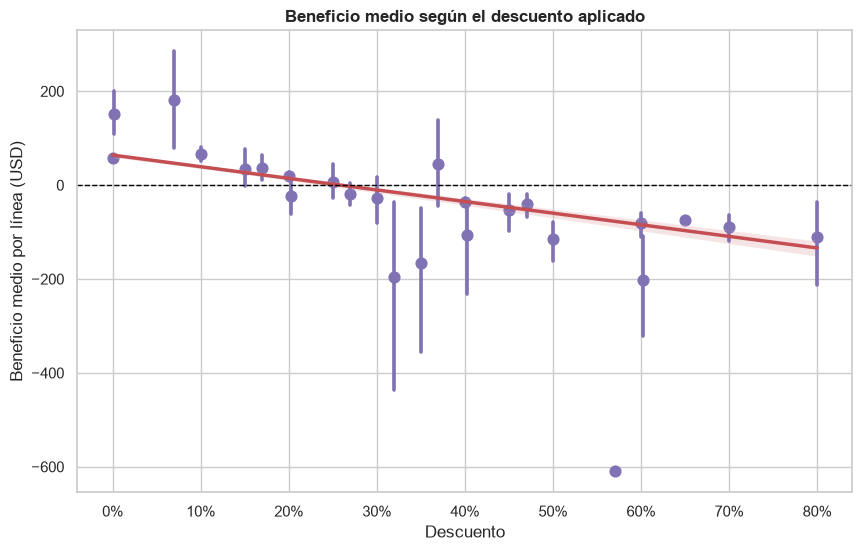

,count,mean,median
Rango Descuento,,,
Sin descuento,2369,58.7,18.3
1-20 %,911,48.4,11.0
21-40 %,375,-36.0,-11.5
Más de 40 %,591,-88.2,-22.8


In [17]:
fig, ax = plt.subplots(figsize=(10, 6))

# x_estimator=np.mean: un punto por nivel de descuento con su media e intervalo de confianza
sns.regplot(data=df, x='Discount', y='Profit', x_estimator=np.mean, color='#8172B3',
            scatter_kws={'s': 60}, line_kws={'color': '#C44E52', 'linewidth': 2.5}, ax=ax)
ax.axhline(0, color='black', linewidth=1, linestyle='--')

ax.set_title('Beneficio medio según el descuento aplicado')
ax.set_xlabel('Descuento')
ax.set_ylabel('Beneficio medio por línea (USD)')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
guardar(fig, '08_regresion_descuento_beneficio.png')
plt.show()

# Resumen numérico por rango de descuento
df.groupby('Rango Descuento', observed=True)['Profit'].agg(['count', 'mean', 'median']).round(1)

# Conclusión: el descuento es el factor que más destruye beneficio. Sin descuento, una línea deja
# de media 58,7 USD; con descuentos de hasta el 20 % todavía gana 48,4 USD, pero a partir del 20 %
# el beneficio medio pasa a ser negativo (-36 USD entre 21-40 % y -88 USD por encima del 40 %).

**Conclusión:** el descuento es lo que más reduce el beneficio. Sin descuento, una línea deja de media **58,7 USD**; con descuentos de hasta el 20 % todavía gana 48,4 USD, pero **a partir del 20 % el beneficio medio se vuelve negativo** (-36 USD entre el 21 y el 40 %, y -88 USD por encima del 40 %).

## 8. Visualizaciones multivariantes con Seaborn

### 8.1 Heatmap de correlación

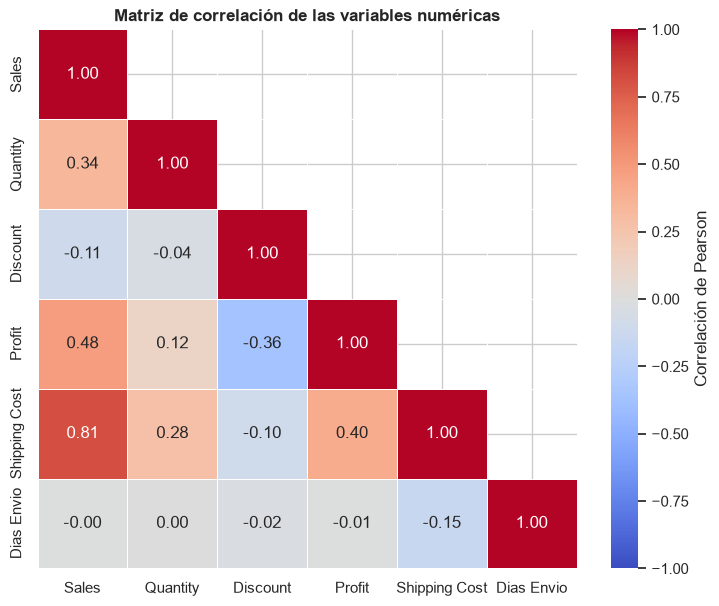

In [18]:
variables = ['Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost', 'Dias Envio']
correlacion = df[variables].corr()

# Máscara para mostrar solo el triángulo inferior (la matriz es simétrica)
mascara = np.triu(np.ones_like(correlacion, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(correlacion, mask=mascara, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, cbar_kws={'label': 'Correlación de Pearson'},
            ax=ax)
ax.set_title('Matriz de correlación de las variables numéricas')
guardar(fig, '09_heatmap_correlacion.png')
plt.show()

# Conclusión: el coste de envío está muy ligado a las ventas (0,81): los pedidos grandes pagan
# más envío. Ventas y beneficio tienen una relación moderada (0,48). El descuento es la única
# variable con correlación negativa clara con el beneficio (-0,36), lo que confirma el gráfico
# anterior. Los días de envío no se relacionan con ninguna variable económica.

**Conclusión:** el **coste de envío** está muy ligado a las **ventas** (0,81). Ventas y beneficio tienen una relación moderada (0,48). El **descuento** es la única variable con correlación negativa clara con el beneficio (-0,36). Los días de envío no se relacionan con ninguna variable económica.

### 8.2 Pairplot por categoría

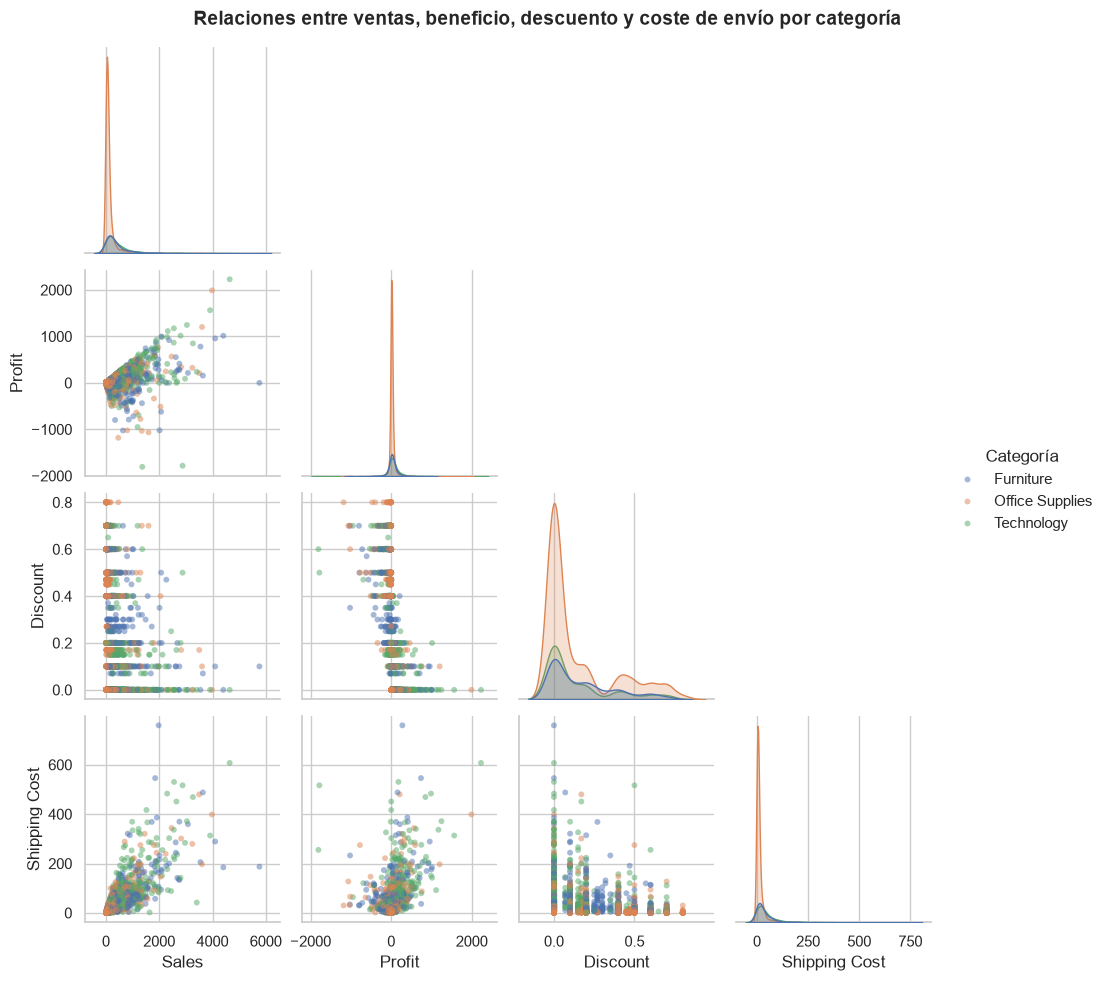

In [19]:
g = sns.pairplot(df, vars=['Sales', 'Profit', 'Discount', 'Shipping Cost'], hue='Category',
                 palette=PALETA_CATEGORIAS, corner=True, diag_kind='kde', height=2.4,
                 plot_kws={'alpha': 0.5, 's': 18, 'edgecolor': 'none'})
g.figure.suptitle('Relaciones entre ventas, beneficio, descuento y coste de envío por categoría',
                  y=1.02, fontsize=14, fontweight='bold')
g._legend.set_title('Categoría')
g.savefig(os.path.join(CARPETA_IMAGENES, '10_pairplot_categorias.png'), dpi=150, bbox_inches='tight')
plt.show()

# Conclusión: Technology (verde) ocupa las zonas de ventas y beneficios más altos, tanto positivos
# como negativos: es la categoría de mayor riesgo y mayor recompensa. Office Supplies se concentra
# en ventas pequeñas. En todas las categorías, los beneficios negativos aparecen con descuentos altos.

**Conclusión:** **Technology** ocupa las zonas de ventas y beneficios más altos, tanto positivos como negativos: es la categoría de mayor riesgo y mayor recompensa. **Office Supplies** se concentra en ventas pequeñas. En todas las categorías, las pérdidas aparecen con descuentos altos.

## 9. Panel de visualizaciones con subplots

Una sola figura con cuatro gráficos distintos que resume el análisis. Se guarda como imagen.

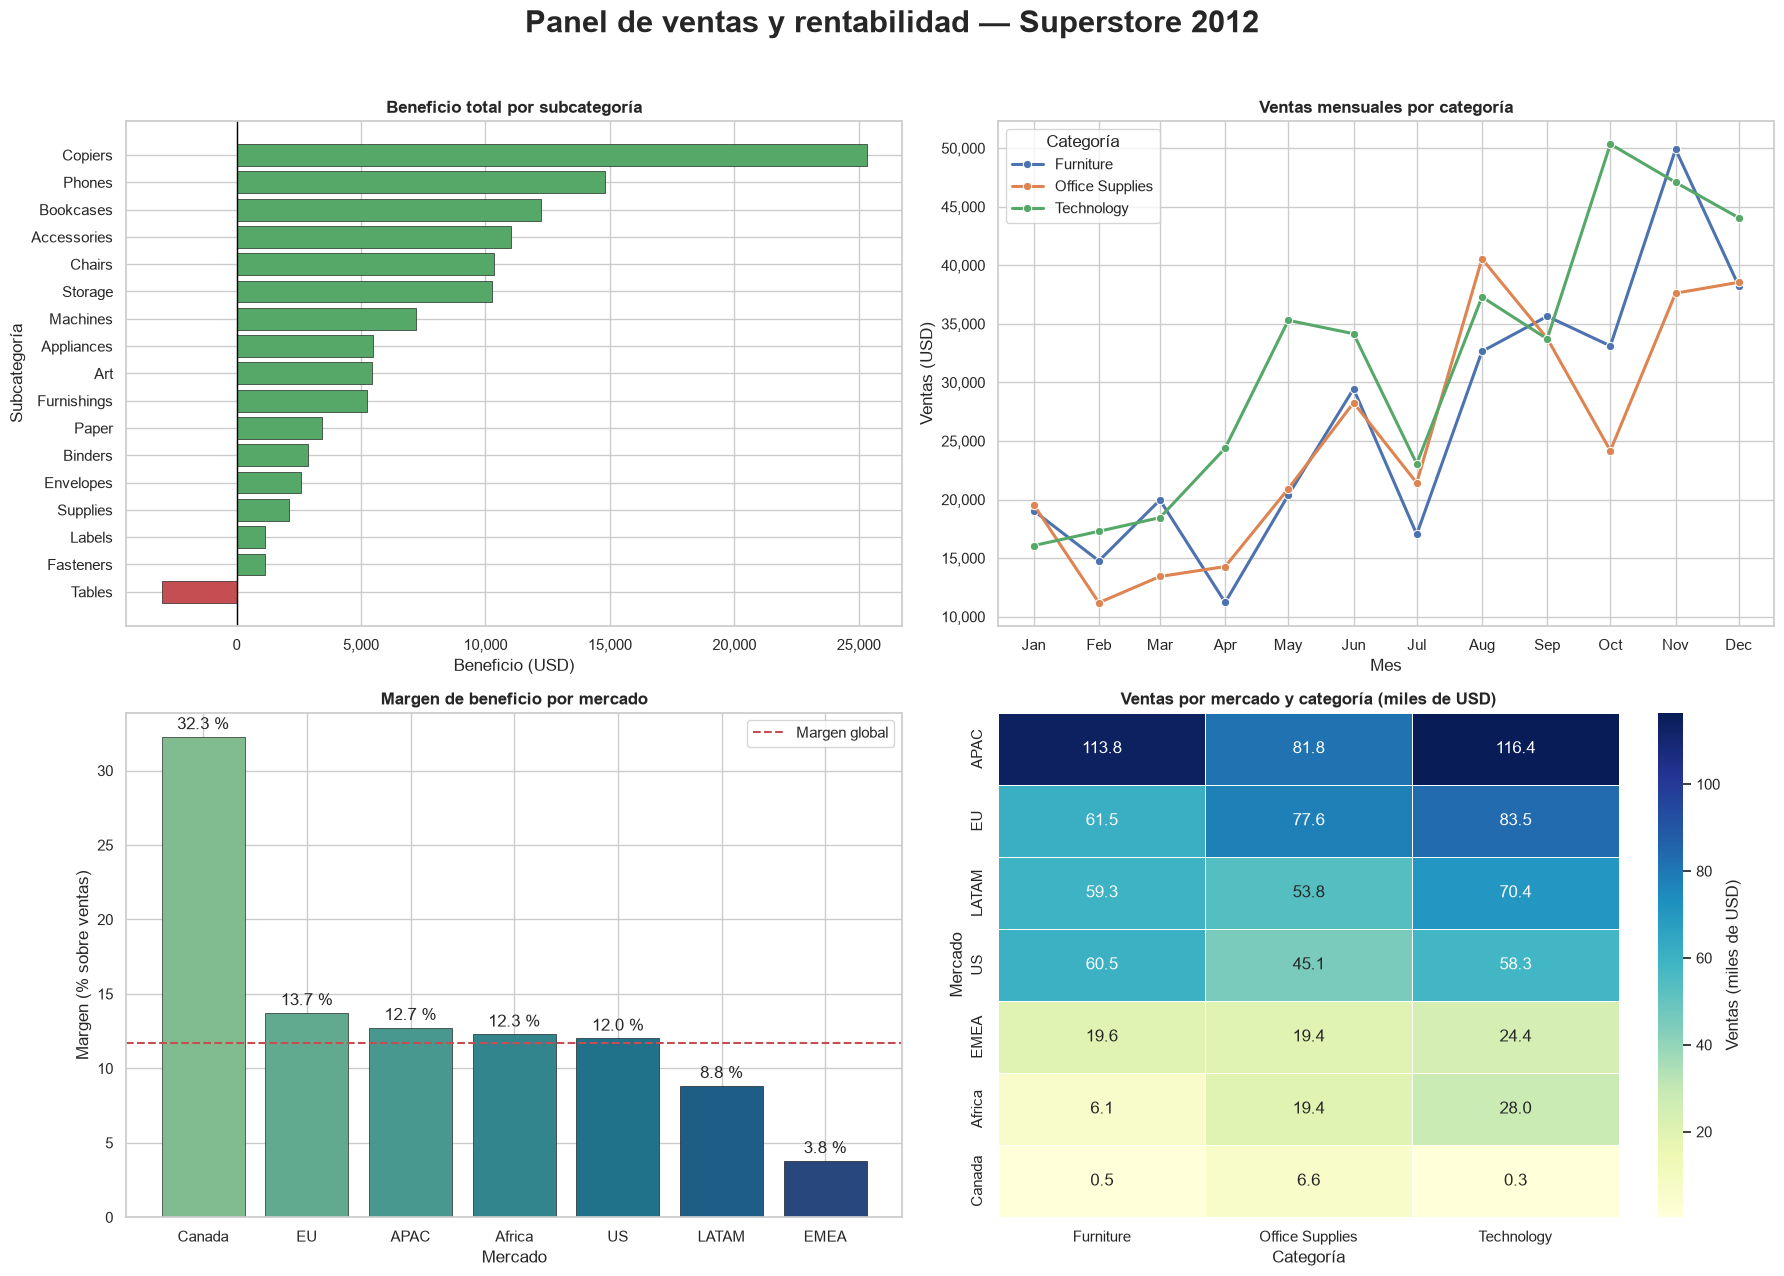

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle('Panel de ventas y rentabilidad — Superstore 2012', fontsize=22, fontweight='bold')

# (1) Matplotlib: beneficio total por subcategoría (barras horizontales)
ax = axes[0, 0]
beneficio_sub = df.groupby('Sub-Category')['Profit'].sum().sort_values()
colores = ['#C44E52' if valor < 0 else '#55A868' for valor in beneficio_sub]
ax.barh(beneficio_sub.index, beneficio_sub.values, color=colores, edgecolor='black', linewidth=0.4)
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Beneficio total por subcategoría')
ax.set_xlabel('Beneficio (USD)')
ax.set_ylabel('Subcategoría')
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

# (2) Seaborn: ventas mensuales por categoría (líneas)
ax = axes[0, 1]
ventas_mes_cat = df.groupby(['Mes', 'Category'], observed=True)['Sales'].sum().reset_index()
sns.lineplot(data=ventas_mes_cat, x='Mes', y='Sales', hue='Category', palette=PALETA_CATEGORIAS,
             marker='o', linewidth=2.2, ax=ax)
ax.set_title('Ventas mensuales por categoría')
ax.set_xlabel('Mes')
ax.set_ylabel('Ventas (USD)')
ax.set_xticks(ventas_mes_cat['Mes'].unique())
ax.set_xticklabels(pd.to_datetime(ventas_mes_cat['Mes'].unique()).strftime('%b'))
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
ax.legend(title='Categoría')

# (3) Matplotlib: margen de beneficio por mercado (barras)
ax = axes[1, 0]
resumen_mercado = df.groupby('Market', observed=True)[['Sales', 'Profit']].sum()
margen_mercado = (resumen_mercado['Profit'] / resumen_mercado['Sales'] * 100).sort_values(ascending=False)
barras = ax.bar(margen_mercado.index, margen_mercado.values,
                color=sns.color_palette('crest', len(margen_mercado)), edgecolor='black', linewidth=0.4)
ax.axhline(resumen_mercado['Profit'].sum() / resumen_mercado['Sales'].sum() * 100,
           color='#C44E52', linestyle='--', label='Margen global')
ax.bar_label(barras, fmt='%.1f %%', padding=3)
ax.set_title('Margen de beneficio por mercado')
ax.set_xlabel('Mercado')
ax.set_ylabel('Margen (% sobre ventas)')
ax.legend()

# (4) Seaborn: heatmap de ventas por mercado y categoría (tabla pivotante)
ax = axes[1, 1]
pivot_ventas = df.pivot_table(values='Sales', index='Market', columns='Category',
                              aggfunc='sum', observed=True) / 1000
sns.heatmap(pivot_ventas.loc[orden_mercados], annot=True, fmt='.1f', cmap='YlGnBu', linewidths=0.5,
            cbar_kws={'label': 'Ventas (miles de USD)'}, ax=ax)
ax.set_title('Ventas por mercado y categoría (miles de USD)')
ax.set_xlabel('Categoría')
ax.set_ylabel('Mercado')

fig.tight_layout(rect=[0, 0, 1, 0.96])
guardar(fig, '11_panel_subplots.png')
plt.show()

# Conclusiones del panel:
# (1) Tables es la única subcategoría con pérdidas (-3.014 USD); Copiers y Phones son las más rentables.
# (2) Las tres categorías crecen en la segunda mitad del año; Technology es la que más vende en 7 de 12 meses.
# (3) Canada tiene el mayor margen (32,3 %) aunque vende muy poco; EMEA el menor (3,8 %), muy por
#     debajo del margen global (11,7 %).
# (4) Las mayores ventas se concentran en APAC (Technology y Furniture) y en EU.

**Conclusiones del panel:**

1. **Tables** es la única subcategoría con pérdidas (-3.014 USD); **Copiers** y **Phones** son las más rentables.
2. Las tres categorías crecen en la segunda mitad del año, y **Technology** es la que más vende en 7 de los 12 meses.
3. **Canada** tiene el mayor margen (32,3 %), aunque vende muy poco; **EMEA** el menor (3,8 %), muy por debajo del margen global (11,7 %).
4. Las mayores ventas se concentran en **APAC** (Technology y Furniture) y en **EU**.

In [21]:
# Imágenes guardadas
sorted(os.listdir(CARPETA_IMAGENES))

['01_histograma_ventas.png',
 '02_barras_segmento.png',
 '03_boxplot_beneficio_categoria.png',
 '04_violin_dias_envio.png',
 '05_lineas_evolucion_mensual.png',
 '06_dispersion_multivariante.png',
 '07_barras_agrupadas_mercado_categoria.png',
 '08_regresion_descuento_beneficio.png',
 '09_heatmap_correlacion.png',
 '10_pairplot_categorias.png',
 '11_panel_subplots.png']

## 10. Conclusiones generales

1. **La venta típica es pequeña.** La mediana por línea de pedido es de 83 USD y unos pocos pedidos grandes elevan la media a 237 USD.
2. **Consumer es el segmento principal** (53,8 % de las líneas), y **APAC, EU y LATAM** son los mercados con más ventas.
3. **Technology es la categoría más rentable** (margen del 15,3 %, frente al 11,3 % de Office Supplies y el 7,7 % de Furniture), pero también la más variable.
4. **El descuento es el principal problema de rentabilidad.** Por encima del 20 %, el beneficio medio por línea es negativo, y el 25,4 % de todas las líneas de pedido genera pérdidas.
5. **Furniture y en concreto Tables** necesitan revisión: Tables es la única subcategoría con pérdidas totales.
6. **EMEA** vende razonablemente pero con un margen de solo el 3,8 %; conviene revisar sus precios y descuentos.
7. **La logística funciona según lo prometido:** cada modo de envío cumple su plazo, y los días de envío no afectan a las ventas ni al beneficio.
8. **Las ventas crecen hacia final de año**, con máximos en noviembre y diciembre, aunque el beneficio no crece al mismo ritmo.

**Recomendación principal:** limitar los descuentos superiores al 20 %, sobre todo en Furniture y en el mercado EMEA, y reforzar la venta de Technology, que combina volumen y margen.